# AlgoPerf: JAX vs. PyTorch Framework Comparison


## 1. Imports & Repo Root

Locates the repo root (so the notebook works whether launched from the root or
from this folder), then imports the scoring package.


In [1]:
import os
import pickle
import sys
from pathlib import Path

# Run everything relative to the repo root so `scoring` imports and the
# repo-relative paths in Section 3 work from any launch directory.
REPO_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'scoring' / 'score_submissions.py').exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tabulate import tabulate

from scoring import performance_profile, scoring_utils
from scoring.config import DEFAULT_TARGETS_PATH, WorkloadConfig


## 2. Configuration

Set the paths and flags below before running the rest of the notebook.

In [2]:
# ── Required ──────────────────────────────────────────────────────────────────
# Path to the directory that contains one sub-folder per submission
# (relative to the repo root).
SUBMISSION_DIRECTORY = 'logs/self_tuning'

# Where to write output CSVs, plots, and LaTeX tables. This is the committed
# artifact directory for the second scoring iteration.
OUTPUT_DIR = 'artifacts/tech_report_v1/jax_vs_pytorch_comparison'

# ── Submission filters (leave empty strings to include/exclude nothing) ───────
# Comma-separated names to include (empty = include all).
INCLUDE_SUBMISSIONS = ''
# Comma-separated names to exclude.
EXCLUDE_SUBMISSIONS = 'muon_torch_jax_hps,muon_torch_jax_hps_achandr,muon_torch_jax_hps_lr_fix,muon_torch_replicated_jax_hps,muon_torch_replicated_torch_hps'

# ── Scoring flags ─────────────────────────────────────────────────────────────
# Set True to enforce the competition's strict trial/study count rules.
STRICT = False
# Set True when scoring the self-tuning ruleset.
SELF_TUNING_RULESET = True
# Set True to compute and plot performance profiles after building summaries.
COMPUTE_PERFORMANCE_PROFILES = True
# Benchmark version config: base/held-out workloads, targets, step hints.
# The score divides by the number of base workloads in this config.
WORKLOAD_CONFIG = WorkloadConfig.from_json(DEFAULT_TARGETS_PATH)

# ── Performance profile parameters ────────────────────────────────────────────
MIN_TAU = 1.0
MAX_TAU = 4.0   # set None to auto-detect from data
NUM_POINTS = 100
SCALE = 'linear'  # 'linear' or 'log'

# ── Caching (optional) ────────────────────────────────────────────────────────
# Save the parsed results dict so you can reload it later without re-parsing.
SAVE_RESULTS_TO = None   # e.g. 'results.pkl'
# Load a previously saved results dict instead of re-parsing.
LOAD_RESULTS_FROM = None  # e.g. 'results.pkl'

os.makedirs(OUTPUT_DIR, exist_ok=True)


## 3. Submission Display-Name Map
Edit the right-hand side to control how names appear in tables and plots.\nAny submission not listed here will be shown with its raw folder name.

In [3]:
# Maps raw folder names → display names used in tables, plots, and LaTeX output.
# Add or edit entries freely; unlisted names fall back to their raw folder name.
SUBMISSION_NAME_MAP = {
    'ademamix':                        'AdEMAMix',
    'cautious_nadamw':                 'Cautious NAdamW',
    'lion':                            'Lion',
    'muon':                            'Muon (JAX)',
    'muon_torch':                      'Muon (PyTorch)',
    'muon_torch_jax_hps':              'Muon (PyTorch, JAX HPs)',
    'muon_torch_jax_hps_achandr':      'Muon (PyTorch, JAX HPs, achandr)',
    'muon_torch_jax_hps_lr_fix':       'Muon (PyTorch, JAX HPs, LR Fix)',
    'muon_torch_replicated_jax_hps':   'Muon (Replicated, JAX HPs)',
    'muon_torch_replicated_torch_hps': 'Muon (Replicated, Torch HPs)',
    'nadamw':                          'NAdamW',
    'nadamw_baselinev05':              'NAdamW (Baseline v0.5)',
    'nadamw_resnet':                   'NAdamW (ResNet)',
    'schedule_free_adamw':             'Schedule-Free AdamW',
    'schedule_free_adamw_jax':         'Schedule-Free AdamW (JAX)',
    'schedule_free_adamw_jax_v2':      'Schedule-Free AdamW (JAX v2)',
    'schedule_free_adamw_v2':          'Schedule-Free AdamW v2',
    'single_worker_diloco':            'DiLoCo (Single Worker)',
    'single_worker_dilocov2':          'DiLoCo v2 (Single Worker)',
}

def pretty(name):
    """Return the display name for a submission, falling back to the raw name."""
    return SUBMISSION_NAME_MAP.get(name, name)

## 4. Helpers: Submission Summary & Leaderboard Score

Imported directly from `scoring/score_submissions.py` so the notebook can never
drift from the official pipeline.


In [4]:
from scoring.score_submissions import (
    compute_leaderboard_score,
    get_submission_summary as _get_submission_summary,
)


def get_submission_summary(df):
    """Canonical per-workload summary, bound to this notebook's config."""
    return _get_submission_summary(df, WORKLOAD_CONFIG)


## 5. Plot Theme

Sets a publication-quality matplotlib style and defines `plot_performance_profiles_styled`.\nWith 19 submissions the plot cycles through 10 colorblind-safe colors × 4 line styles so it stays readable in greyscale and print.

In [5]:
import itertools
import math
import matplotlib as mpl

# ── Colorblind-safe 10-color palette (Paul Tol "bright") ──────────────────────
_COLORS = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#BBBBBB',  # grey
    '#EE7733',  # orange
    '#009988',  # teal
    '#CC3311',  # vermillion
]
_LINE_STYLES = ['-', '--', '-.', ':']

# 10 solid lines, then 9 dashed, etc. — enough for 19 submissions.
_STYLE_CYCLE = list(itertools.islice(
    ((c, ls) for ls in _LINE_STYLES for c in _COLORS),
    40,
))

# ── rcParams: tuned for a two-column tech-report (e.g. NeurIPS / ICML) ────────
mpl.rcParams.update({
    'figure.figsize':        (9, 4.5),
    'figure.dpi':            150,
    'savefig.dpi':           300,
    'savefig.bbox':          'tight',
    'savefig.pad_inches':    0.05,
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'font.size':             11,
    'axes.titlesize':        11,
    'axes.labelsize':        11,
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       8.5,
    'legend.title_fontsize': 9,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#cccccc',
    'legend.borderpad':      0.5,
    'legend.labelspacing':   0.35,
    'axes.grid':             True,
    'grid.alpha':            0.3,
    'grid.linestyle':        '--',
    'grid.linewidth':        0.6,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.linewidth':        0.8,
    'lines.linewidth':       1.6,
})


def plot_performance_profiles_styled(
    perf_df,
    df_col,
    scale='linear',
    save_dir=None,
    figsize=(9, 4.5),
    title=None,
):
    """
    Publication-quality performance profile plot for a tech report.

    Each submission gets a unique (color, line-style) pair so the figure
    remains legible in greyscale and for colorblind readers.
    The legend is placed below the plot.
    Saves both a vector PDF and a 300-dpi PNG.
    """
    style_iter = iter(_STYLE_CYCLE)

    fig, ax = plt.subplots(figsize=figsize)

    for submission in perf_df.index:
        color, linestyle = next(style_iter)
        ax.plot(
            perf_df.columns,
            perf_df.loc[submission],
            label=submission,
            color=color,
            linestyle=linestyle,
            linewidth=1.6,
            alpha=0.92,
        )

    ax.set_xlabel('Performance ratio τ  (relative to best submission)')
    ax.set_ylabel('Fraction of workloads solved ρ(τ)')
    ax.set_xlim(perf_df.columns.min(), perf_df.columns.max())
    ax.set_ylim(-0.02, 1.05)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1, decimals=0))

    if title:
        ax.set_title(title, pad=8)

    # ── Legend below the axes ──────────────────────────────────────────────────
    n = len(perf_df.index)
    ncol = max(3, math.ceil(n / 4))   # ~4 rows for any submission count
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.16),
        ncol=ncol,
        borderaxespad=0,
        frameon=True,
        handlelength=2.0,
        handleheight=0.9,
        columnspacing=1.0,
        labelspacing=0.35,
    )

    # Reserve vertical space proportional to the number of legend rows so the
    # legend never overlaps the x-axis label.
    n_rows = math.ceil(n / ncol)
    pts_per_row = mpl.rcParams['legend.fontsize'] * 1.55
    fig_height_pts = figsize[1] * 72
    legend_frac = (n_rows * pts_per_row + 28) / fig_height_pts
    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.91 if title else 0.97,
        bottom=min(0.10 + legend_frac, 0.55),
    )

    if save_dir:
        base = os.path.join(save_dir, f'performance_profile_by_{df_col}')
        fig.savefig(f'{base}.pdf', format='pdf')
        fig.savefig(f'{base}.png', format='png', dpi=300)
        print(f'Saved → {base}.pdf / .png')

    return fig, ax

## 6. Load & Summarize Submissions

In [6]:
results = {}

_exclude     = {s.strip() for s in EXCLUDE_SUBMISSIONS.split(',')} - {''}
_include_raw = {s.strip() for s in INCLUDE_SUBMISSIONS.split(',')} - {''}

print(f'Excluding ({len(_exclude)}): {sorted(_exclude) or "(none)"}')
print(f'Including ({len(_include_raw)}): {sorted(_include_raw) or "(all)"}')

def _is_included(raw_name):
    if raw_name in _exclude:
        return False
    if _include_raw and raw_name not in _include_raw:
        return False
    return True

if LOAD_RESULTS_FROM:
    load_path = os.path.join(OUTPUT_DIR, LOAD_RESULTS_FROM)
    print(f'\nLoading cached results from {load_path}')
    with open(load_path, 'rb') as f:
        cached = pickle.load(f)
    _pretty_to_raw = {v: k for k, v in SUBMISSION_NAME_MAP.items()}
    for name, df in cached.items():
        raw = _pretty_to_raw.get(name, name)
        if _is_included(raw):
            results[name] = df
            print(f'  ✓ {name}')
        else:
            print(f'  ✗ {name}  ← excluded')
else:
    all_submission_dirs = sorted(os.listdir(SUBMISSION_DIRECTORY))
    print(f'\nFound {len(all_submission_dirs)} folders:')
    for s in all_submission_dirs:
        tag = '✓' if _is_included(s) else '✗  ← excluded'
        print(f'  {tag} {s}')
    print()

    for submission in all_submission_dirs:
        if not _is_included(submission):
            continue
        print(f'\n=== {pretty(submission)} ({submission}) ===')
        experiment_path = os.path.join(SUBMISSION_DIRECTORY, submission)
        df = scoring_utils.get_experiment_df(experiment_path)
        results[pretty(submission)] = df

        summary_df = get_submission_summary(df)
        summary_df.to_csv(os.path.join(OUTPUT_DIR, f'{submission}_summary.csv'))
        display(summary_df)

    if SAVE_RESULTS_TO:
        save_path = os.path.join(OUTPUT_DIR, SAVE_RESULTS_TO)
        with open(save_path, 'wb') as f:
            pickle.dump(results, f)
        print(f'Results cached to {save_path}')

print(f'\nLoaded {len(results)} submission(s): {list(results.keys())}')

Excluding (5): ['muon_torch_jax_hps', 'muon_torch_jax_hps_achandr', 'muon_torch_jax_hps_lr_fix', 'muon_torch_replicated_jax_hps', 'muon_torch_replicated_torch_hps']
Including (0): (all)

Found 19 folders:
  ✓ ademamix
  ✓ cautious_nadamw
  ✓ lion
  ✓ muon
  ✓ muon_torch
  ✗  ← excluded muon_torch_jax_hps
  ✗  ← excluded muon_torch_jax_hps_achandr
  ✗  ← excluded muon_torch_jax_hps_lr_fix
  ✗  ← excluded muon_torch_replicated_jax_hps
  ✗  ← excluded muon_torch_replicated_torch_hps
  ✓ nadamw
  ✓ nadamw_baselinev05
  ✓ nadamw_resnet
  ✓ schedule_free_adamw
  ✓ schedule_free_adamw_jax
  ✓ schedule_free_adamw_jax_v2
  ✓ schedule_free_adamw_v2
  ✓ single_worker_diloco
  ✓ single_worker_dilocov2


=== AdEMAMix (ademamix) ===
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet_vit_pytorch', 'librispeech_conformer_pytorch', 'ogbg_pytorch', 'librispeech_deepspeech_pytorch', 'wmt_pytorch', 'criteo1tb_pytorch', 'finewebedu_lm_pytorch']
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet

,workload,trial,val target metric name,val target metric value,val target reached,best metric value on val,time to best eval on val (s),time to target on val (s),step_time (s),step_hint
7,criteo1tb_pytorch,trial_1,validation/loss,0.123735,True,0.123685,7839.193164,7.839193e+03,1.001083,10666
16,criteo1tb_pytorch,trial_1,validation/loss,0.123735,False,0.124211,13214.635874,inf,1.001083,10666
24,criteo1tb_pytorch,trial_1,validation/loss,0.123735,True,0.123650,7835.540827,7.479551e+03,1.001083,10666
1,fastmri_pytorch,trial_1,validation/ssim,0.723653,True,0.724810,1311.107364,1.311107e+03,0.942039,18094
10,fastmri_pytorch,trial_1,validation/ssim,0.723653,True,0.724951,1517.732191,1.517732e+03,0.942039,18094
19,fastmri_pytorch,trial_1,validation/ssim,0.723653,True,0.724894,1555.368783,1.555369e+03,0.942039,18094
8,finewebedu_lm_pytorch,trial_1,validation/ppl,22.299500,True,22.140829,18025.636203,1.802564e+04,0.404032,72000
17,finewebedu_lm_pytorch,trial_1,validation/ppl,22.299500,True,22.234960,18027.619179,1.802762e+04,0.404032,72000
25,finewebedu_lm_pytorch,trial_1,validation/ppl,22.299500,True,22.247438,18025.896891,1.802590e+04,0.404032,72000
0,imagenet_resnet_pytorch,trial_1,validation/accuracy,0.774310,False,0.602180,59997.685173,inf,0.674003,195999



=== Cautious NAdamW (cautious_nadamw) ===
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
                      workload                                        trial  \
0          imagenet_resnet_jax  (trial_1, logs/self_tuning/cautious_nadamw)   
1                  fastmri_jax  (trial_1, logs/self_tuning/cautious_nadamw)   
2                      wmt_jax  (trial_1, logs/self_tuning/cautious_nadamw)   
3                     ogbg_jax  (trial_1, logs/self_tuning/cautious_nadamw)   
4    librispeech_conformer_jax  (trial_1, logs/self_tuning/cautious

,workload,trial,val target metric name,val target metric value,val target reached,best metric value on val,time to best eval on val (s),time to target on val (s),step_time (s),step_hint
7,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.125700,2863.657990,inf,0.926635,10666
15,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.125837,1792.004785,inf,0.926635,10666
24,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124694,9989.461620,inf,0.926635,10666
1,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.724439,1608.188659,1.608189e+03,0.655975,18094
9,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.723893,1383.159640,1.383160e+03,0.655975,18094
17,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.723682,2571.815328,2.571815e+03,0.655975,18094
23,finewebedu_lm_jax,trial_1,validation/ppl,22.299500,True,21.632686,25738.981688,2.573898e+04,0.441446,72000
0,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.746600,69885.510298,inf,0.251495,195999
8,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.747480,67896.184145,inf,0.251495,195999
16,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.749640,61917.019345,inf,0.251495,195999



=== Lion (lion) ===
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet_vit_pytorch', 'librispeech_conformer_pytorch', 'ogbg_pytorch', 'librispeech_deepspeech_pytorch', 'wmt_pytorch', 'criteo1tb_pytorch', 'finewebedu_lm_pytorch']
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet_vit_pytorch', 'librispeech_conformer_pytorch', 'ogbg_pytorch', 'librispeech_deepspeech_pytorch', 'wmt_pytorch', 'criteo1tb_pytorch', 'finewebedu_lm_pytorch']
['imagenet_resnet_pytorch', 'fastmri_pytorch', 'imagenet_vit_pytorch', 'librispeech_conformer_pytorch', 'ogbg_pytorch', 'librispeech_deepspeech_pytorch', 'wmt_pytorch', 'criteo1tb_pytorch', 'finewebedu_lm_pytorch']
                          workload                             trial    study  \
0          imagenet_resnet_pytorch  (trial_1, logs/self_tuning/lion)  study_2   
1                  fastmri_pytorch  (trial_1, logs/self_tuning/lion)  study_2   
2             imagenet_vit_pytorch  (trial_1, logs/self_tuning/lion)  study_2   
3    libri

...


=== DiLoCo (Single Worker) (single_worker_diloco) ===
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
                      workload  \
0          imagenet_resnet_jax   
1                  fastmri_jax   
2                      wmt_jax   
3                     ogbg_jax   
4    librispeech_conformer_jax   
5   librispeech_deepspeech_jax   
6             imagenet_vit_jax   
7            finewebedu_lm_jax   
8                criteo1tb_jax   
9          imagenet_resnet_jax   
10                 fastmri_jax   


,workload,trial,val target metric name,val target metric value,val target reached,best metric value on val,time to best eval on val (s),time to target on val (s),step_time (s),step_hint
8,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124005,12536.648544,inf,2.029254,10666
17,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124177,13238.606914,inf,2.029254,10666
25,criteo1tb_jax,trial_1,validation/loss,0.123735,True,0.123679,8951.699251,8.951699e+03,2.029254,10666
1,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.724345,1824.361733,1.824362e+03,1.010139,18094
10,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.724033,2934.323400,2.934323e+03,1.010139,18094
7,finewebedu_lm_jax,trial_1,validation/ppl,22.299500,True,21.299927,28315.804241,2.831580e+04,0.461929,72000
16,finewebedu_lm_jax,trial_1,validation/ppl,22.299500,True,21.323351,28314.819189,2.831482e+04,0.461929,72000
24,finewebedu_lm_jax,trial_1,validation/ppl,22.299500,True,21.302589,28313.505345,2.831351e+04,0.461929,72000
0,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.758640,59924.762427,inf,0.254795,195999
9,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.760840,73905.253106,inf,0.254795,195999



=== DiLoCo v2 (Single Worker) (single_worker_dilocov2) ===
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
['imagenet_resnet_jax', 'fastmri_jax', 'wmt_jax', 'ogbg_jax', 'librispeech_conformer_jax', 'librispeech_deepspeech_jax', 'imagenet_vit_jax', 'finewebedu_lm_jax', 'criteo1tb_jax']
                      workload  \
0          imagenet_resnet_jax   
1                  fastmri_jax   
2                      wmt_jax   
3                     ogbg_jax   
4    librispeech_conformer_jax   
5   librispeech_deepspeech_jax   
6             imagenet_vit_jax   
7            finewebedu_lm_jax   
8                criteo1tb_jax   
9          imagenet_resnet_jax   
10                 fastmri_ja

,workload,trial,val target metric name,val target metric value,val target reached,best metric value on val,time to best eval on val (s),time to target on val (s),step_time (s),step_hint
8,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124271,13033.471937,inf,1.957256,10666
17,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124327,12450.281544,inf,1.957256,10666
25,criteo1tb_jax,trial_1,validation/loss,0.123735,False,0.124366,12143.230377,inf,1.957256,10666
1,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.724679,3013.444574,3.013445e+03,1.213146,18094
10,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.723714,2578.141947,2.578142e+03,1.213146,18094
19,fastmri_jax,trial_1,validation/ssim,0.723653,True,0.723721,2561.646830,2.561647e+03,1.213146,18094
7,finewebedu_lm_jax,trial_1,validation/ppl,22.299500,True,21.837119,28313.973881,2.831397e+04,0.474875,72000
16,finewebedu_lm_jax,trial_1,validation/ppl,22.299500,True,21.668298,28312.441187,2.831244e+04,0.474875,72000
24,finewebedu_lm_jax,trial_1,validation/ppl,22.299500,True,22.063855,28316.034054,2.831603e+04,0.474875,72000
0,imagenet_resnet_jax,trial_1,validation/accuracy,0.774310,False,0.735240,71938.876954,inf,0.494305,195999



Loaded 14 submission(s): ['AdEMAMix', 'Cautious NAdamW', 'Lion', 'Muon (JAX)', 'Muon (PyTorch)', 'NAdamW', 'NAdamW (Baseline v0.5)', 'NAdamW (ResNet)', 'Schedule-Free AdamW', 'Schedule-Free AdamW (JAX)', 'Schedule-Free AdamW (JAX v2)', 'Schedule-Free AdamW v2', 'DiLoCo (Single Worker)', 'DiLoCo v2 (Single Worker)']


## 7. Framework Comparison: JAX vs. PyTorch

Three algorithms have implementations in both frameworks (Schedule-Free AdamW
v1/v2 and Muon). Each pair runs the same algorithm with the same batch sizes on
nearly every workload, so differences between the two versions measure the
frameworks rather than the optimizers. Emits `framework_comparison.{pdf,png}`:
a heatmap of the per-example step time ratio (JAX / PyTorch); the colorbar
ticks repeat the same ratio values shown in the cells.


per-example step-time ratio (JAX/PT):
                        Criteo  fastMRI  FineWeb  ResNet   ViT  Conformer  \
Schedule-Free AdamW       1.77     2.39     1.15    0.33  0.60       3.45   
Schedule-Free AdamW v2    1.02     0.51     1.14    0.52  0.58       3.63   
Muon                      2.12     1.38     1.28    0.78  0.61       3.29   

                        DeepSpeech  OGBG   WMT  
Schedule-Free AdamW           2.89  0.86  0.89  
Schedule-Free AdamW v2        5.43  0.89  0.94  
Muon                          3.43  0.82  1.20  
Saved -> framework_comparison.pdf / .png


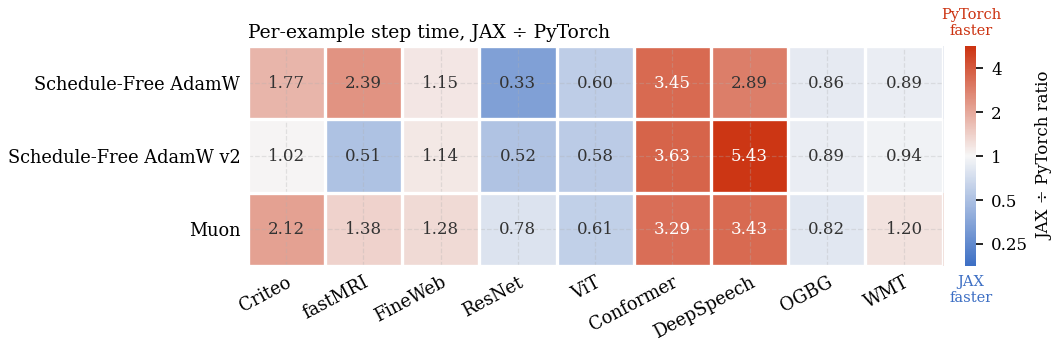

In [7]:
# ── JAX vs PyTorch: paired-algorithm framework comparison ────────────────────
import re
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

WORKLOADS = ['criteo1tb', 'fastmri', 'finewebedu_lm', 'imagenet_resnet',
             'imagenet_vit', 'librispeech_conformer', 'librispeech_deepspeech',
             'ogbg', 'wmt']
WL_SHORT = ['Criteo', 'fastMRI', 'FineWeb', 'ResNet', 'ViT', 'Conformer',
            'DeepSpeech', 'OGBG', 'WMT']

# (row label, pytorch submission, jax submission)
PAIRS = [
    ('Schedule-Free AdamW', 'Schedule-Free AdamW', 'Schedule-Free AdamW (JAX)'),
    ('Schedule-Free AdamW v2', 'Schedule-Free AdamW v2', 'Schedule-Free AdamW (JAX v2)'),
    ('Muon', 'Muon (PyTorch)', 'Muon (JAX)'),
]

# Training batch sizes from each submission's get_batch_size().
BATCH_PT_SFA = {'criteo1tb': 262144, 'fastmri': 16, 'finewebedu_lm': 64,
                'imagenet_resnet': 1024, 'imagenet_vit': 1024,
                'librispeech_conformer': 224, 'librispeech_deepspeech': 128,
                'ogbg': 512, 'wmt': 128}
BATCH_JAX_SFA = {**BATCH_PT_SFA, 'fastmri': 32, 'finewebedu_lm': 32,
                 'librispeech_conformer': 256}
BATCH_MUON = {'criteo1tb': 262144, 'fastmri': 32, 'finewebedu_lm': 64,
              'imagenet_resnet': 1024, 'imagenet_vit': 1024,
              'librispeech_conformer': 256, 'librispeech_deepspeech': 256,
              'ogbg': 512, 'wmt': 128}
BATCHES = {
    'Schedule-Free AdamW': (BATCH_PT_SFA, BATCH_JAX_SFA),
    'Schedule-Free AdamW v2': (BATCH_PT_SFA, BATCH_JAX_SFA),
    'Muon': (BATCH_MUON, BATCH_MUON),
}


def step_times(sub):
    """Median seconds per step, per base workload."""
    df = results[sub]
    out = {}
    for workload, group in df.groupby('workload'):
        base = re.sub(r'_(jax|pytorch)$', '', workload)
        ratios = []
        for _, trial in group.iterrows():
            t = np.diff(np.asarray(trial['accumulated_submission_time']), prepend=0)
            s = np.diff(np.asarray(trial['global_step']), prepend=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                ratios.append(np.nanmedian(t / s))
        out[base] = float(np.median(ratios))
    return out

step_ratio = np.full((len(PAIRS), len(WORKLOADS)), np.nan)

for i, (label, pt, jx) in enumerate(PAIRS):
    st_pt, st_jx = step_times(pt), step_times(jx)
    b_pt, b_jx = BATCHES[label]
    for j, w in enumerate(WORKLOADS):
        per_ex_pt = st_pt[w] / b_pt[w]
        per_ex_jx = st_jx[w] / b_jx[w]
        step_ratio[i, j] = per_ex_jx / per_ex_pt

print('per-example step-time ratio (JAX/PT):')
print(pd.DataFrame(step_ratio, index=[p[0] for p in PAIRS], columns=WL_SHORT).round(2))

# ── Figure: single heatmap, print-true at \textwidth = 6.5in ──────────────────
# Cells show the raw JAX ÷ PyTorch ratio; the colorbar ticks repeat those
# ratio values (0.25 … 4) so the legend numbers match the box numbers.
JAX_C, PT_C, MID_C = '#3D6FC4', '#CC3311', '#f7f7f7'
cmap = LinearSegmentedColormap.from_list('fw', [JAX_C, MID_C, PT_C])
norm = TwoSlopeNorm(vmin=-2.5, vcenter=0.0, vmax=2.5)

fig, ax = plt.subplots(figsize=(6.5, 1.9))

log = np.log2(step_ratio)
masked = np.ma.masked_invalid(log)
ax.imshow(masked, cmap=cmap, norm=norm, aspect='auto')
for i in range(step_ratio.shape[0]):
    for j in range(step_ratio.shape[1]):
        v = step_ratio[i, j]
        ax.text(j, i, f'{v:.2f}' if v < 10 else f'{v:.0f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(np.log2(v)) > 1.6 else '#333333')
ax.set_yticks(range(step_ratio.shape[0]))
ax.set_yticklabels([p[0] for p in PAIRS], fontsize=8.5)
ax.set_xticks(range(len(WL_SHORT)))
ax.set_xticklabels(WL_SHORT, fontsize=8.5, rotation=28, ha='right',
                   rotation_mode='anchor')
ax.set_title('Per-example step time, JAX ÷ PyTorch', fontsize=9, loc='left', pad=4)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for j in range(step_ratio.shape[1] + 1):
    ax.axvline(j - .5, color='white', lw=1.6)
for i in range(step_ratio.shape[0] + 1):
    ax.axhline(i - .5, color='white', lw=1.6)

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                    fraction=0.05, pad=0.03, ticks=[-2, -1, 0, 1, 2])
cbar.ax.set_yticklabels(['0.25', '0.5', '1', '2', '4'], fontsize=8)
cbar.set_label('JAX ÷ PyTorch ratio', fontsize=8)
cbar.ax.text(0.5, 1.04, 'PyTorch\nfaster', transform=cbar.ax.transAxes,
             ha='center', va='bottom', fontsize=7, color=PT_C)
cbar.ax.text(0.5, -0.04, 'JAX\nfaster', transform=cbar.ax.transAxes,
             ha='center', va='top', fontsize=7, color=JAX_C)
cbar.outline.set_visible(False)

OUT = OUTPUT_DIR
for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(OUT, f'framework_comparison.{ext}'), format=ext, dpi=300)
print('Saved -> framework_comparison.pdf / .png')
plt.show()
